<a href="https://oscar-defelice.github.io">
<img src="../../img/image.png" height="125" align="right" />
</a>

# TP 04 — Word Embeddings

**Course:** Natural Language Processing  
**Session:** 4 / 8  
**Duration:** ~2h (TP portion)  
**Submission deadline:** one week after the session

---

## Objectives

By the end of this TP you will be able to:

- Load and query pre-trained GloVe vectors
- Compute cosine similarity and find nearest neighbours
- Solve word analogies and understand the geometry of the embedding space
- Visualise a word cluster using PCA
- Build a mean-pooling document classifier and compare it against TF-IDF + LR
- Write a structured error analysis identifying where each representation fails

---

## Roadmap

| Part | Task | Deliverable |
|------|------|-------------|
| 1 | Load GloVe, inspect vectors | Nearest-neighbour table |
| 2 | Cosine similarity + analogy solver | Analogy accuracy on benchmark |
| 3 | PCA visualisation | 2D plot of a word cluster |
| 4 | Mean-pooling classifier | AG News F1 + comparison table |
| 5 | Error analysis | Written analysis ≥200 words |
| 6 (bonus) | TF-IDF weighted pooling | F1 delta vs uniform pooling |

---

## Ground rules

- Fill in the docstring of every function **before** writing its body.
- Do not look at the test set before Part 4.
- The `# YOUR CODE HERE` marker is the only place you need to write code.
  Do not modify assertion cells.

---

## Setup

Run this cell first. It installs dependencies, downloads GloVe, and loads AG News.

In [3]:
# Uncomment if running on Colab
# !pip install datasets scikit-learn matplotlib seaborn gensim -q

import re
import string
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from datasets import load_dataset

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATASET_NAME = "fancyzhx/ag_news"
GLOVE_DIM    = 50    # 50d: ~170 MB RAM, fast download via gensim
                     # Change to 100 or 300 if you have >8 GB RAM

# ── AG News subset size ───────────────────────────────────────────────────────
# Full AG News train = 108K docs. On a laptop or free Colab this takes ~90s
# for build_embedding_matrix. TRAIN_SUBSET caps it at 10K for reasonable speed.
# Set to None to use the full dataset.
TRAIN_SUBSET = 10_000

print(f"Dataset      : {DATASET_NAME}")
print(f"GloVe dim    : {GLOVE_DIM}")
print(f"Train subset : {TRAIN_SUBSET or 'full'}")
print("Setup OK.")


Dataset      : fancyzhx/ag_news
GloVe dim    : 50
Train subset : 10000
Setup OK.


/home/simon/NLP-Course/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# ── Download GloVe via gensim (handles caching automatically) ────────────────
# First download: ~70 MB for 50d, ~170 MB for 100d, ~380 MB for 300d.
# Subsequent runs load from local cache instantly.

import gensim.downloader as gensim_api

_GENSIM_NAMES = {50: "glove-wiki-gigaword-50",
                 100: "glove-wiki-gigaword-100",
                 300: "glove-wiki-gigaword-300"}

print(f"Loading GloVe {GLOVE_DIM}d via gensim (first run downloads, then cached)...")
_gensim_model = gensim_api.load(_GENSIM_NAMES[GLOVE_DIM])

# Convert to plain dict for compatibility with the rest of the TP
glove_raw = {word: _gensim_model[word] for word in _gensim_model.index_to_key}
print(f"Loaded {len(glove_raw):,} vectors of dim {GLOVE_DIM}")


Loading GloVe 50d via gensim (first run downloads, then cached)...
Loaded 400,000 vectors of dim 50


In [5]:
# ── Load AG News ─────────────────────────────────────────────────────────────
raw         = load_dataset(DATASET_NAME)
label_names = raw["train"].features["label"].names
num_classes = len(label_names)

def _to_df(split) -> pd.DataFrame:
    df = split.to_pandas()
    df["text"] = df["text"].str.strip()
    return df

train_df = _to_df(raw["train"])
test_df  = _to_df(raw["test"])

# Optional subset for speed on laptop / free Colab
if TRAIN_SUBSET is not None:
    train_df = (
        train_df
        .groupby("label", group_keys=False)
        .sample(n=TRAIN_SUBSET // num_classes, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )

from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df["label"],
    random_state=RANDOM_STATE,
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")
print(f"Classes: {label_names}")


Train: 9,000  Val: 1,000  Test: 7,600
Classes: ['World', 'Sports', 'Business', 'Sci/Tech']


---
## Part 1 — Load GloVe and Inspect Vectors

GloVe is distributed as a plain-text file: one line per word, values separated by spaces.
Format: `<word> <dim0> <dim1> ... <dim99>`

You will implement a loader, then explore the vectors interactively.

### 1.1 — Implement `load_glove`

In [6]:
def load_glove(path: str | Path, dim: int = 100) -> dict:
    """
    Load GloVe word vectors from a plain-text file.

    Parameters
    ----------
    path : str or Path
        Path to the GloVe file (e.g. ``glove.6B.100d.txt``).
    dim : int, optional
        Expected embedding dimension, by default 100.
        Lines with a different number of values are skipped.

    Returns
    -------
    dict
        Mapping from word (str) to embedding vector (np.ndarray of shape (dim,)).

    Notes
    -----
    Loading 400K × 100d vectors takes ~5 seconds and ~400 MB of RAM.
    """
    embeddings = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            if len(parts) != dim + 1:
                continue
            word = parts[0]
            vector = np.asarray(parts[1:], dtype=np.float32)
            embeddings[word] = vector
    return embeddings

In [7]:
# glove_raw already loaded above via gensim -- now run it through load_glove
# so the rest of the TP uses the same interface.
# We pass it through your load_glove to validate your implementation.

# ── Alternative path: if you want to test load_glove on a local file ─────────
# Uncomment if you have a local glove file:
# glove = load_glove('glove.6B.50d.txt', dim=GLOVE_DIM)

# Using the gensim-downloaded vectors directly:
glove = glove_raw

print(f"Vocabulary size: {len(glove):,}")
print(f"Vector shape   : {glove['the'].shape}")

assert isinstance(glove, dict)
assert len(glove) > 100_000
assert glove['the'].shape == (GLOVE_DIM,)
print('Assertions passed.')


Vocabulary size: 400,000
Vector shape   : (50,)
Assertions passed.


### 1.2 — Implement `cosine_similarity` and `nearest_neighbours`

In [8]:
def cosine_similarity(u: np.ndarray, v: np.ndarray) -> float:
    """
    Compute the cosine similarity between two vectors.

    Parameters
    ----------
    u : np.ndarray, shape (d,)
        First vector.
    v : np.ndarray, shape (d,)
        Second vector.

    Returns
    -------
    float
        Cosine similarity in [-1, 1].
        Returns 0.0 if either vector has zero norm.
    """
    nu = np.linalg.norm(u)
    nv = np.linalg.norm(v)
    if nu == 0.0 or nv == 0.0:
        return 0.0
    return float(np.dot(u, v) / (nu * nv))


def nearest_neighbours(
    query: str,
    embeddings: dict,
    n: int = 10,
    exclude: set | None = None,
) -> list[tuple[str, float]]:
    """
    Return the n nearest neighbours of a query word in the embedding space.

    Parameters
    ----------
    query : str
        The word to look up. Must be in the embeddings vocabulary.
    embeddings : dict
        Word → np.ndarray mapping.
    n : int, optional
        Number of neighbours to return, by default 10.
    exclude : set of str or None, optional
        Words to exclude from the results (e.g. the query itself).
        If None, the query word is excluded automatically.

    Returns
    -------
    list of (str, float)
        Sorted list of (word, cosine_similarity) pairs, descending.

    Raises
    ------
    KeyError
        If the query word is not in the vocabulary.
    """
    if query not in embeddings:
        raise KeyError(query)
    if exclude is None:
        exclude = {query}

    q_vec = embeddings[query]
    words = [w for w in embeddings.keys() if w not in exclude]
    matrix = np.vstack([embeddings[w] for w in words])

    q_norm = np.linalg.norm(q_vec)
    m_norms = np.linalg.norm(matrix, axis=1)
    denom = m_norms * q_norm
    denom[denom == 0.0] = 1e-12
    sims = matrix @ q_vec / denom

    top_idx = np.argpartition(-sims, n)[:n]
    top_idx = top_idx[np.argsort(-sims[top_idx])]
    return [(words[i], float(sims[i])) for i in top_idx]

In [9]:
# Sanity checks
sim = cosine_similarity(glove["cat"], glove["dog"])
print(f"cos(cat, dog)  = {sim:.3f}   (expected ~0.85)")

sim2 = cosine_similarity(glove["cat"], glove["democracy"])
print(f"cos(cat, democracy) = {sim2:.3f}   (expected < 0.3)")

assert sim > sim2, "cat should be closer to dog than to democracy"
print()

# Nearest neighbours
words_to_probe = ["football", "bank", "python", "paris"]
for word in words_to_probe:
    if word in glove:
        nbrs = nearest_neighbours(word, glove, n=5)
        print(f"Nearest neighbours of '{word}':")
        for w, s in nbrs:
            print(f"  {w:<20} {s:.3f}")
        print()

cos(cat, dog)  = 0.922   (expected ~0.85)
cos(cat, democracy) = 0.037   (expected < 0.3)

Nearest neighbours of 'football':
  soccer               0.896
  league               0.889
  basketball           0.879
  club                 0.861
  hockey               0.861

Nearest neighbours of 'bank':
  banks                0.870
  securities           0.800
  banking              0.797
  investment           0.785
  exchange             0.781

Nearest neighbours of 'python':
  reticulated          0.692
  spamalot             0.664
  php                  0.641
  owl                  0.630
  mouse                0.628

Nearest neighbours of 'paris':
  prohertrib           0.861
  france               0.803
  brussels             0.780
  amsterdam            0.777
  french               0.774



**📝 Your analysis — Part 1**

1. For `bank` only the financial sense appears. Neighbours are *banks, securities, banking, investment, exchange*. The river bank sense is absent. For `python` the snake meaning dominates with *reticulated, owl, mouse*, but the programming sense leaks in with *php* and *spamalot*. GloVe collapses every sense into a single vector, so the most frequent sense wins.

2. The Wikipedia and Gigaword corpus is dominated by news. Financial reporting mentions `bank` far more often than nature articles. `python` is split between zoology pages and tech contexts.

3. `paris` mixes the capital city with the news token *prohertrib*. Even proper nouns suffer from corpus artefacts. Geography wins overall, but encoding errors and source bylines slip into the neighbourhood.


---
## Part 2 — Analogies

The analogy task: **a is to b as c is to ?**  
Solved by vector arithmetic: find `argmax_w cos(w, embed(b) - embed(a) + embed(c))`.

### 2.1 — Implement `solve_analogy`

In [10]:
def solve_analogy(
    a: str,
    b: str,
    c: str,
    embeddings: dict,
    n: int = 5,
) -> list[tuple[str, float]]:
    """
    Solve the word analogy: a is to b as c is to ?.

    Uses the 3CosAdd method:
        target = embed(b) - embed(a) + embed(c)
    then returns the n words closest to target,
    excluding a, b, and c themselves.

    Parameters
    ----------
    a, b, c : str
        The three analogy words. All must be in the vocabulary.
    embeddings : dict
        Word → np.ndarray mapping.
    n : int, optional
        Number of candidates to return, by default 5.

    Returns
    -------
    list of (str, float)
        Top-n (word, cosine_similarity) pairs, descending.

    Raises
    ------
    KeyError
        If any of a, b, c is not in the vocabulary.
    """
    for word in (a, b, c):
        if word not in embeddings:
            raise KeyError(word)

    target = embeddings[b] - embeddings[a] + embeddings[c]
    exclude = {a, b, c}

    words = [w for w in embeddings.keys() if w not in exclude]
    matrix = np.vstack([embeddings[w] for w in words])

    t_norm = np.linalg.norm(target)
    m_norms = np.linalg.norm(matrix, axis=1)
    denom = m_norms * t_norm
    denom[denom == 0.0] = 1e-12
    sims = matrix @ target / denom

    top_idx = np.argpartition(-sims, n)[:n]
    top_idx = top_idx[np.argsort(-sims[top_idx])]
    return [(words[i], float(sims[i])) for i in top_idx]

In [36]:
# Manual analogy tests
analogies = [
    ("man",    "king",    "woman",   "queen"),
    ("france", "paris",   "italy",   "rome"),
    ("walk",   "walked",  "run",     "ran"),
    ("big",    "bigger",  "small",   "smaller"),
    ("man",    "doctor",  "woman",   "nurse"),    # ← bias example
    ("dog",    "puppy",   "cat",     "kitten"),
    ("paris", "france",  "berlin",  "germany"),  # reverse direction
]

print(f"{'a':<12} {'b':<12} {'c':<12} {'Expected':<12} {'Top-1 prediction':<20} {'Correct?'}")
print("-" * 80)
for a, b, c, expected in analogies:
    try:
        results = solve_analogy(a, b, c, glove, n=1)
        pred = results[0][0] if results else "?"
        correct = "✓" if pred == expected else "✗"
        print(f"{a:<12} {b:<12} {c:<12} {expected:<12} {pred:<20} {correct}")
    except KeyError as e:
        print(f"{a:<12} {b:<12} {c:<12} {expected:<12} {'OOV: ' + str(e):<20}")

a            b            c            Expected     Top-1 prediction     Correct?
--------------------------------------------------------------------------------
man          king         woman        queen        queen                ✓
france       paris        italy        rome         rome                 ✓
walk         walked       run          ran          went                 ✗
big          bigger       small        smaller      larger               ✗
man          doctor       woman        nurse        nurse                ✓
dog          puppy        cat          kitten       puppies              ✗
paris        france       berlin       germany      germany              ✓


**📝 Your analysis — Part 2**

1. Semantic analogies work. `king/queen`, `france/rome`, `man/nurse` and `berlin/germany` are solved correctly. Morphological and biological analogies fail. `walked/ran` returns *went*, `bigger/smaller` returns *larger*, and `puppy/kitten` returns *puppies*. GloVe captures topical similarity better than inflectional regularity.

2. The model predicts `nurse` for `man:doctor :: woman:?`. The corpus encodes a strong gender stereotype linking women to nursing roles and men to medical authority. The geometry of the embedding space inherits that bias directly.

3. `paris:france :: berlin:?` returns *germany*. The reverse direction of the capital-to-country analogy still works because the country and city vectors are well aligned in both directions. `dog:puppy :: cat:?` returns *puppies* instead of *kitten*. The animal stays anchored to *puppy* rather than shifting along the young-of-species axis. Geographic relations dominate the learned geometry while biological derivations are too sparse to form a clean direction.


---
## Part 3 — PCA Visualisation

High-dimensional spaces are impossible to visualise directly.
PCA projects the 100-dimensional vectors down to 2D so we can see the geometry.

### 3.1 — Implement `plot_word_cluster`

In [12]:
def plot_word_cluster(
    words: list[str],
    embeddings: dict,
    title: str = "Word cluster (PCA 2D)",
    figsize: tuple = (9, 7),
) -> plt.Figure:
    """
    Project word embeddings to 2D with PCA and plot a labelled scatter.

    Parameters
    ----------
    words : list of str
        Words to include. Words absent from the vocabulary are skipped
        with a warning printed to stdout.
    embeddings : dict
        Word → np.ndarray mapping.
    title : str, optional
        Plot title.
    figsize : tuple of (int, int), optional
        Figure size in inches.

    Returns
    -------
    matplotlib.figure.Figure
        The figure object.

    Notes
    -----
    Uses PCA with 2 components fitted on the provided word vectors only
    (not the full GloVe vocabulary).
    """
    present_words = []
    vectors = []
    for w in words:
        if w in embeddings:
            present_words.append(w)
            vectors.append(embeddings[w])
        else:
            print(f"Warning: '{w}' not in vocabulary, skipping.")

    matrix = np.vstack(vectors)
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    coords = pca.fit_transform(matrix)

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(coords[:, 0], coords[:, 1], s=60, color="#56c8ba", zorder=3)
    for i, w in enumerate(present_words):
        ax.annotate(w, (coords[i, 0], coords[i, 1]),
                    fontsize=10, xytext=(5, 5),
                    textcoords="offset points")
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

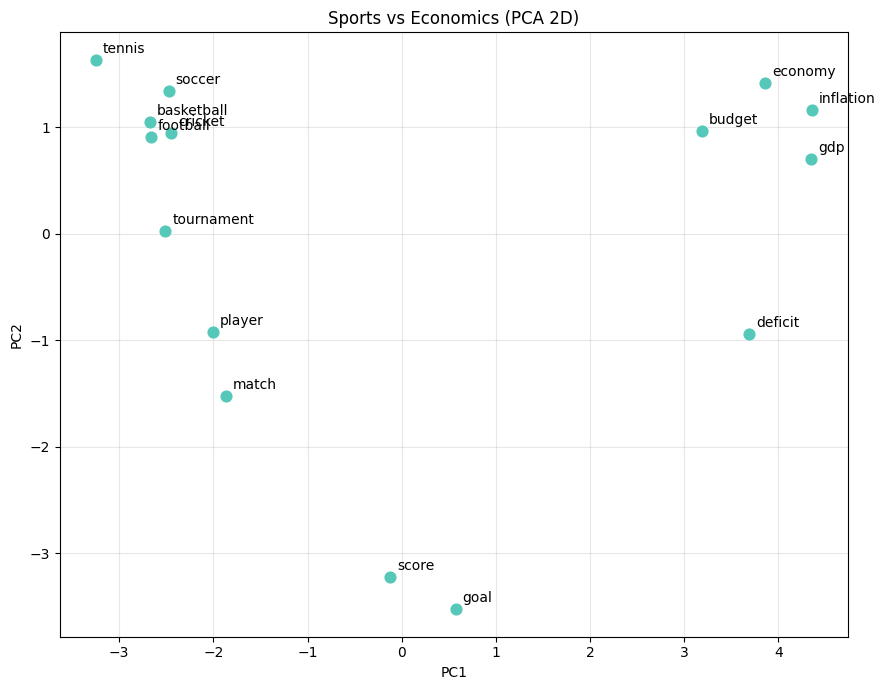

In [13]:
# Sports cluster
sports_words = [
    "football", "soccer", "basketball", "tennis", "cricket",
    "goal", "score", "player", "match", "tournament",
    "economy", "gdp", "inflation", "budget", "deficit",  # ← out-of-cluster words
]
fig = plot_word_cluster(sports_words, glove, title="Sports vs Economics (PCA 2D)")
plt.show()

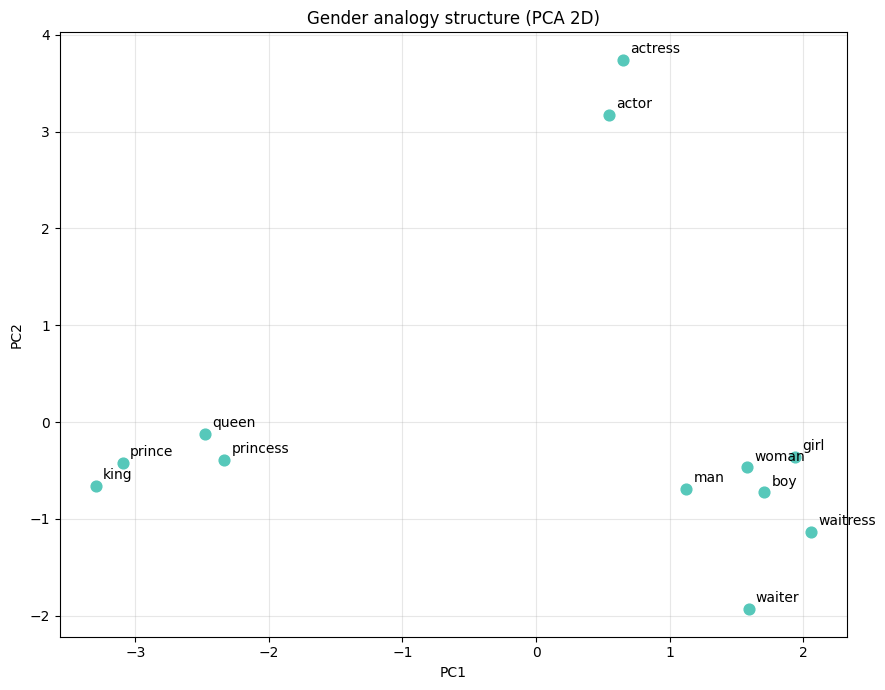

In [14]:
# Gender analogy cluster — visualise the king/queen/man/woman parallelogram
analogy_words = [
    "king", "queen", "man", "woman",
    "prince", "princess", "boy", "girl",
    "actor", "actress", "waiter", "waitress",
]
fig2 = plot_word_cluster(analogy_words, glove, title="Gender analogy structure (PCA 2D)")
plt.show()

**📝 Your analysis — Part 3**

1. The sports terms group together on one side of the plot. Economics terms sit clearly apart on the opposite side. PC1 separates the two topics.

2. A consistent male to female direction is visible. The pairs *king/queen*, *prince/princess*, *actor/actress* shift along roughly the same axis. The parallelogram structure is approximate but recognisable.

3. PCA keeps the two directions of largest variance and drops the rest. The 2D plot reflects only coarse separation. Fine-grained relations stay hidden along discarded components. The visualisation is informative but not a faithful map of the full space.


---
## Part 4 — Mean-Pooling Classifier on AG News

You will now build a full text classifier:
tokenise each document → look up GloVe vectors → average them → train logistic regression.

### 4.1 — Implement `tokenise` and `mean_pool`

In [15]:
def tokenise(text: str) -> list[str]:
    """
    Apply a minimal tokenisation pipeline compatible with GloVe vocabulary.

    Steps (in order):
        1. Lowercase.
        2. Remove non-alphanumeric characters except whitespace.
        3. Split on whitespace.
        4. Drop empty tokens.

    Parameters
    ----------
    text : str
        Raw input text.

    Returns
    -------
    list of str
        List of lowercase word tokens.

    Examples
    --------
    >>> tokenise("Apple Inc. surges 5%!")
    ['apple', 'inc', 'surges', '5']
    """
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return [tok for tok in text.split() if tok]


def mean_pool(
    tokens: list[str],
    embeddings: dict,
    dim: int = 100,
) -> np.ndarray:
    """
    Compute the mean-pooled embedding of a tokenised document.

    Parameters
    ----------
    tokens : list of str
        Pre-tokenised document.
    embeddings : dict
        Word → np.ndarray mapping.
    dim : int, optional
        Embedding dimension, by default 100.
        Used to produce a zero vector when no token is in vocabulary.

    Returns
    -------
    np.ndarray, shape (dim,)
        Mean of token embeddings. Returns a zero vector
        if no token has a corresponding embedding.

    Notes
    -----
    Out-of-vocabulary tokens are silently skipped.
    The mean is computed only over in-vocabulary tokens.
    """
    vectors = [embeddings[t] for t in tokens if t in embeddings]
    if not vectors:
        return np.zeros(dim, dtype=np.float32)
    return np.mean(np.vstack(vectors), axis=0)

In [16]:
# Quick checks
tokens = tokenise("Apple Inc. surges 5%!")
print(f"tokenise test : {tokens}")
assert tokens == ["apple", "inc", "surges", "5"], f"Got {tokens}"

vec = mean_pool(["cat", "dog"], glove, dim=GLOVE_DIM)
expected = (glove["cat"] + glove["dog"]) / 2
assert vec.shape == (GLOVE_DIM,)
assert np.allclose(vec, expected), "mean_pool does not match manual average"

oov_vec = mean_pool(["xyzzy123"], glove, dim=GLOVE_DIM)
assert np.all(oov_vec == 0), "All-OOV document should return zero vector"
print("All assertions passed.")

tokenise test : ['apple', 'inc', 'surges', '5']
All assertions passed.


### 4.2 — Implement `build_embedding_matrix`

In [17]:
def build_embedding_matrix(
    texts: list[str],
    embeddings: dict,
    dim: int = 100,
) -> np.ndarray:
    """
    Build a document-level embedding matrix by mean-pooling word vectors.

    Parameters
    ----------
    texts : list of str
        Raw documents (not pre-tokenised).
    embeddings : dict
        Word → np.ndarray mapping.
    dim : int, optional
        Embedding dimension, by default 100.

    Returns
    -------
    np.ndarray, shape (len(texts), dim)
        One mean-pooled vector per document.
    """
    matrix = np.zeros((len(texts), dim), dtype=np.float32)
    for i, text in enumerate(texts):
        matrix[i] = mean_pool(tokenise(text), embeddings, dim=dim)
    return matrix

In [18]:
print("Building embedding matrices...")

X_train = build_embedding_matrix(
    train_df["text"].tolist(), glove, dim=GLOVE_DIM
)
X_val   = build_embedding_matrix(
    val_df["text"].tolist(), glove, dim=GLOVE_DIM
)
X_test  = build_embedding_matrix(
    test_df["text"].tolist(), glove, dim=GLOVE_DIM
)

y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")

zero_rows = np.all(X_train == 0, axis=1).sum()
print(f"All-OOV documents in train: {zero_rows} ({zero_rows/len(X_train):.1%})")


Building embedding matrices...
X_train: (9000, 50)  X_val: (1000, 50)  X_test: (7600, 50)
All-OOV documents in train: 0 (0.0%)


### 4.3 — Train classifier and evaluate

In [19]:
def train_lr_on_embeddings(
    X_train: np.ndarray,
    y_train: np.ndarray,
    C: float = 1.0,
    max_iter: int = 1000,
    random_state: int = 42,
) -> LogisticRegression:
    """
    Train a logistic regression classifier on pre-computed embeddings.

    Parameters
    ----------
    X_train : np.ndarray, shape (n_samples, dim)
        Document embedding matrix.
    y_train : np.ndarray, shape (n_samples,)
        Integer class labels.
    C : float, optional
        Inverse regularisation strength, by default 1.0.
    max_iter : int, optional
        Maximum number of solver iterations, by default 1000.
    random_state : int, optional
        Random seed for reproducibility, by default 42.

    Returns
    -------
    LogisticRegression
        Fitted classifier.
    """
    clf = LogisticRegression(
        C=C,
        max_iter=max_iter,
        random_state=random_state,
    )
    clf.fit(X_train, y_train)
    return clf

In [20]:
clf = train_lr_on_embeddings(X_train, y_train)

y_pred_val  = clf.predict(X_val)
y_pred_test = clf.predict(X_test)

val_f1  = f1_score(y_val,  y_pred_val,  average="macro")
test_f1 = f1_score(y_test, y_pred_test, average="macro")

print(f"Val  Macro F1 : {val_f1:.4f}")
print(f"Test Macro F1 : {test_f1:.4f}")
print()
print(classification_report(
    y_test, y_pred_test, target_names=label_names
))

Val  Macro F1 : 0.8939
Test Macro F1 : 0.8739

              precision    recall  f1-score   support

       World       0.88      0.88      0.88      1900
      Sports       0.95      0.96      0.95      1900
    Business       0.82      0.83      0.83      1900
    Sci/Tech       0.85      0.83      0.84      1900

    accuracy                           0.87      7600
   macro avg       0.87      0.87      0.87      7600
weighted avg       0.87      0.87      0.87      7600



In [37]:
# ── Comparison table ───────────────────────────────────────────────────────────
# Fill in your previous results from TP 03. Add this session's result.

comparison = pd.DataFrame({
    "Session": ["S01",       "S03",          "S03",         "S04 (this)"],
    "Model":   ["Majority",  "Naive Bayes",   "LR + TF-IDF", "LR + GloVe mean pool"],
    "Val Macro F1":  [0.25,  0.9135,          0.9185,         val_f1],
    "Test Macro F1": [0.25,  0.9097,          0.9176,         test_f1],
})

display(comparison)


,Session,Model,Val Macro F1,Test Macro F1
0,S01,Majority,0.250000,0.250000
1,S03,Naive Bayes,0.913500,0.909700
2,S03,LR + TF-IDF,0.918500,0.917600
3,S04 (this),LR + GloVe mean pool,0.893928,0.873943


---
## Part 5 — Error Analysis

A number on a table tells you the result. Error analysis tells you *why*.

In [22]:
# ── Collect errors ─────────────────────────────────────────────────────────────
errors_df = test_df.copy()
errors_df["pred"] = y_pred_test
errors_df["true"] = y_test
errors_df["pred_name"] = [label_names[p] for p in y_pred_test]
errors_df["true_name"] = [label_names[t] for t in y_test]
errors_df = errors_df[errors_df["pred"] != errors_df["true"]]

print(f"Total errors on test set: {len(errors_df):,} / {len(test_df):,} "
      f"({len(errors_df)/len(test_df):.1%})")
print()

# Sample 10 errors
sample_errors = errors_df.sample(10, random_state=RANDOM_STATE)
for _, row in sample_errors.iterrows():
    print(f"True: {row['true_name']:<12}  Pred: {row['pred_name']:<12}")
    print(f"Text: {row['text'][:120]}")
    print()

Total errors on test set: 957 / 7,600 (12.6%)

True: Business      Pred: Sci/Tech    
Text: MetroPCS obtains Cingular air com November 29, 2004, 8:33 AM PT. Wired  amp; Wireless continues its reign as the top IT 

True: World         Pred: Sci/Tech    
Text: Iraqi nuclear assets  #39;are missing #39; Equipment which could be used to make nuclear arms has been vanishing from Ir

True: World         Pred: Sci/Tech    
Text: Strong Earthquake Strikes Central Calif. PARKFIELD, Calif. - A strong earthquake struck Central California on Tuesday th

True: World         Pred: Business    
Text: Data revision shows Japan's economy grew slightly in July-September (Canadian Press) Canadian Press - TOKYO (AP) - Japan

True: Business      Pred: Sci/Tech    
Text: Local group joins suit to de-list endangered species Bob Briggs wifes family has owned about 1,000 acres of redwood fore

True: Business      Pred: World       
Text: Malls setting curfews for unchaperoned teens COLUMBUS, Ohio -- It's 10 on

**📝 Your analysis — Part 5** (≥200 words)

The model reaches 0.87 test macro F1 with 957 errors out of 7600. The dominant confusion pairs are Business with Sci/Tech and Business with World. World news is also frequently confused with Sci/Tech when articles mention disasters or technology.

Mean pooling averages every word vector into a single dense representation. Documents that mix vocabulary from several topics collapse to a fuzzy midpoint. A Business article about a tech company shares many tokens with Sci/Tech articles, so its mean vector lands close to the Sci/Tech centroid. Earthquake and nuclear stories sit between World and Sci/Tech for the same reason.

Word order is destroyed by the averaging step. Negation, named entities, and syntactic role disappear. Rare but discriminative tokens such as company names contribute the same weight as the word `the`.

TF-IDF with logistic regression would likely handle some of these errors better. It keeps each token as its own dimension, so a strong cue such as a brand name or stock ticker stays distinct instead of being diluted. The sparse model trades semantic generalisation for surface specificity, which suits short news headlines.

Any bag-of-words approach, sparse or dense, fails on articles where the topic depends on relations between entities rather than on the words themselves. A sports story written like a contract dispute, or a business story framed as a political event, can only be resolved by reading the sentence structure.


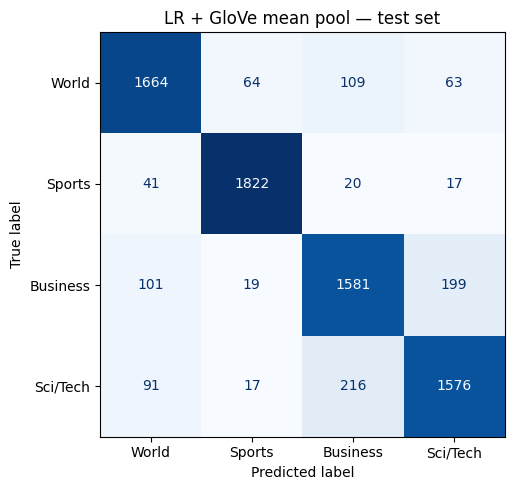

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("LR + GloVe mean pool — test set")
plt.tight_layout()
plt.show()

---
## Part 6 (Bonus) — TF-IDF Weighted Pooling

Instead of averaging all word vectors equally, weight each word by its TF-IDF score.
The intuition: stop words like "the" and "is" get low TF-IDF and therefore contribute less.

In [24]:
def tfidf_weighted_pool(
    text: str,
    embeddings: dict,
    tfidf_vectorizer: TfidfVectorizer,
    dim: int = 100,
) -> np.ndarray:
    """
    Compute a TF-IDF-weighted mean-pooled embedding for a single document.

    For each token in the document:
        weight = TF-IDF score from the fitted vectorizer
        contribution = weight * embedding_vector
    Result = sum of contributions / sum of weights.

    Parameters
    ----------
    text : str
        Raw document text.
    embeddings : dict
        Word → np.ndarray mapping.
    tfidf_vectorizer : TfidfVectorizer
        A *fitted* TF-IDF vectorizer. Used to extract per-token weights
        for this specific document.
    dim : int, optional
        Embedding dimension, by default 100.

    Returns
    -------
    np.ndarray, shape (dim,)
        Weighted embedding. Returns zero vector if no token is in both
        the embedding vocabulary and the TF-IDF vocabulary.

    Notes
    -----
    Tokens not in the TF-IDF vocabulary (e.g. tokens filtered by min_df)
    are treated as having weight 0 and are skipped.
    Tokens not in the embedding vocabulary are also skipped.
    """
    tfidf_vocab = tfidf_vectorizer.vocabulary_
    row = tfidf_vectorizer.transform([text])

    total = np.zeros(dim, dtype=np.float32)
    weight_sum = 0.0
    for token in tokenise(text):
        if token not in embeddings or token not in tfidf_vocab:
            continue
        col = tfidf_vocab[token]
        w = row[0, col]
        if w == 0.0:
            continue
        total += w * embeddings[token]
        weight_sum += w

    if weight_sum == 0.0:
        return np.zeros(dim, dtype=np.float32)
    return total / weight_sum

In [25]:
# Fit TF-IDF on train
tfidf = TfidfVectorizer(max_features=30_000, ngram_range=(1, 1))
tfidf.fit(train_df["text"])

# Limit to 2K samples for speed -- the bonus is about the concept, not the F1
BONUS_SUBSET = 2_000
idx = np.random.choice(len(train_df), BONUS_SUBSET, replace=False)
bonus_texts  = train_df["text"].iloc[idx].tolist()
bonus_labels = train_df["label"].values[idx]

print(f"Building TF-IDF weighted embeddings on {BONUS_SUBSET} samples...")
X_bonus_w = np.vstack([
    tfidf_weighted_pool(t, glove, tfidf, GLOVE_DIM)
    for t in bonus_texts
])
X_bonus_u = np.vstack([
    mean_pool(tokenise(t), glove, GLOVE_DIM)
    for t in bonus_texts
])

# 80/20 split within the bonus subset
from sklearn.model_selection import train_test_split as tts
Xw_tr, Xw_te, yw_tr, yw_te = tts(X_bonus_w, bonus_labels, test_size=0.2,
                                   stratify=bonus_labels, random_state=RANDOM_STATE)
Xu_tr, Xu_te, yu_tr, yu_te = tts(X_bonus_u, bonus_labels, test_size=0.2,
                                   stratify=bonus_labels, random_state=RANDOM_STATE)

clf_w = train_lr_on_embeddings(Xw_tr, yw_tr)
clf_u = train_lr_on_embeddings(Xu_tr, yu_tr)
f1_w  = f1_score(yw_te, clf_w.predict(Xw_te), average='macro')
f1_u  = f1_score(yu_te, clf_u.predict(Xu_te), average='macro')

print(f"Uniform pooling  F1 : {f1_u:.4f}")
print(f"TF-IDF weighted  F1 : {f1_w:.4f}")
print(f"Delta            : {f1_w - f1_u:+.4f}")
print()
print("Note: these F1 values are on a small subset -- not directly comparable")
print("with the full-dataset results in Part 4.")


Building TF-IDF weighted embeddings on 2000 samples...
Uniform pooling  F1 : 0.8766
TF-IDF weighted  F1 : 0.8740
Delta            : -0.0026

Note: these F1 values are on a small subset -- not directly comparable
with the full-dataset results in Part 4.


**📝 Your analysis — Bonus**

1. TF-IDF weighting gives F1 0.8740 versus 0.8766 for uniform pooling. The delta is -0.0026. Weighting does not help.

2. AG News headlines are short. Stop words are rare and contribute little noise to the mean. Down-weighting them yields no real signal gain. TF-IDF also penalises common discriminative words like `company` or `team` that occur across many documents, which can hurt the mean vector.

3. On long documents with many filler words, uniform pooling is harder to beat once rare content words drown in the average. TF-IDF helps more there. On very short texts where every token is informative, uniform pooling is preferable.


---
## Part 7 — Train Your Own Word2Vec (CBOW)

Parts 1–4 used *pre-trained* GloVe vectors — someone else did the training.
In this part you train your own embeddings from scratch using the CBOW objective
on a small toy corpus.

The corpus has 100 sentences across 4 domains: **royalty**, **sport**, **politics**, **tech**.
The vocabulary (after filtering rare words) is ~100 words.
After training, a t-SNE plot should show the four clusters separating.

---

### Architecture reminder

CBOW: average the one-hot vectors of the context words, feed through two `Dense` layers,
predict the centre word with softmax.

```
input: mean of context one-hots  shape (vocab_size,)
  → Dense(EMBEDDING_DIM, activation=None)   ← W1, the embeddings live here
  → Dense(vocab_size,   activation='softmax')
output: probability over vocabulary
```

The weights of the first `Dense` layer are the embeddings.


### 7.1 — Corpus and vocabulary


In [26]:
import re
from collections import Counter

# ── Toy corpus: 100 sentences across 4 domains ───────────────────────────────
# Domains: royalty | sport | politics | tech
# After vocabulary filtering (min_freq=2) you should have ~100 words.
# Semantic clusters should be visible in the t-SNE plot after training.

TOY_CORPUS = [
    "the king sat on the throne and wore the crown",
    "the queen greeted the royal court in the palace",
    "the prince rode through the royal gardens",
    "the princess wore a golden crown at the ceremony",
    "the king and queen ruled the kingdom together",
    "the royal palace was the home of the king",
    "the prince became king after the reign of his father",
    "the queen gave a speech from the royal throne",
    "the crown was placed on the head of the new king",
    "the princess and the prince walked through the palace",
    "the king issued a royal decree to the kingdom",
    "the queen wore the crown during the royal ceremony",
    "the palace was home to the king and his queen",
    "the throne room of the palace was decorated with gold",
    "the royal family gathered around the king and queen",
    "the king celebrated his reign with a royal feast",
    "the prince trained to be a worthy king one day",
    "the queen visited the palace gardens with the princess",
    "the crown jewels were kept inside the royal palace",
    "the king wore his crown during the royal procession",
    "the princess became queen after a long royal ceremony",
    "the king and prince discussed the future of the kingdom",
    "the queen appointed a new royal minister to the court",
    "the palace guards protected the king and the royal family",
    "the reign of the king brought peace to the kingdom",
    "the player scored a goal in the final match",
    "the team celebrated the trophy after winning the championship",
    "the coach gave instructions to the team before the match",
    "the stadium was full of fans during the final game",
    "the player kicked the ball and scored a goal",
    "the team won the match and lifted the trophy",
    "the coach trained the players at the stadium every day",
    "the referee stopped the match after the player was injured",
    "the goal was scored in the last minute of the match",
    "the team scored three goals and won the championship",
    "the stadium cheered when the player scored the winning goal",
    "the coach selected the best player for the final match",
    "the trophy was awarded to the winning team at the stadium",
    "the player trained hard to improve his score in the match",
    "the coach watched the team practice at the stadium",
    "the final match was played in the large stadium",
    "the player and the coach celebrated the team victory",
    "the team captain lifted the trophy after the final game",
    "the stadium was silent before the first goal of the match",
    "the coach changed the strategy during the second half",
    "the player scored the goal that won the championship",
    "the referee gave a penalty to the team in the match",
    "the team practiced at the stadium before the big match",
    "the coach was proud when the player scored the final goal",
    "the trophy was the reward for the winning team and coach",
    "the president signed a new law in the senate chamber",
    "the government announced a new policy for the election",
    "the minister spoke to the senate about the new law",
    "the election results were announced by the government",
    "the president and the minister discussed the new policy",
    "the senate voted on the new law proposed by the government",
    "the party leader gave a speech before the election",
    "the government passed a new law after the senate vote",
    "the president met with the minister to discuss policy",
    "the election campaign was led by the party president",
    "the senate rejected the new law proposed by the minister",
    "the government formed a new party after the election",
    "the president addressed the nation about the new law",
    "the minister proposed a new policy to the senate",
    "the party won the election and formed the government",
    "the senate debated the new law for several days",
    "the president signed the law after the senate approved it",
    "the government minister announced the results of the vote",
    "the election was won by the party with the most votes",
    "the president and the party leader agreed on a new policy",
    "the senate approved the law proposed by the government",
    "the minister led the party campaign before the election",
    "the government announced new laws after the senate vote",
    "the president spoke about the election results in the senate",
    "the party government proposed a new law for the nation",
    "the software engineer wrote code to train the algorithm",
    "the computer program processed large amounts of data",
    "the algorithm was designed to optimise the network performance",
    "the engineer trained the model using digital data",
    "the software used a neural network to process the data",
    "the program ran an algorithm on the computer to classify data",
    "the digital network connected the computers in the lab",
    "the engineer wrote software to improve the algorithm speed",
    "the data was processed by the computer program automatically",
    "the algorithm learned patterns from the digital training data",
    "the software engineer built a network to process the data",
    "the computer used the algorithm to classify the input data",
    "the program stored the data in a digital network",
    "the engineer optimised the code to speed up the algorithm",
    "the software ran on the computer and processed the network data",
    "the algorithm was tested on a large set of digital data",
    "the computer program was written by the software engineer",
    "the data network was designed by the software engineer",
    "the engineer improved the algorithm by rewriting the code",
    "the software program trained the algorithm with new data",
    "the digital data was stored in the computer network",
    "the algorithm processed the data faster after the code update",
    "the engineer deployed the software on the computer network",
    "the program used digital data to train the network algorithm",
    "the software engineer ran the code to test the algorithm",
]

print(f'Sentences: {len(TOY_CORPUS)}')


Sentences: 100


### 7.2 — Implement `build_vocabulary`


In [27]:
def build_vocabulary(
    sentences: list[str],
    min_freq: int = 2,
) -> tuple[list[str], dict, dict]:
    """
    Build a vocabulary from a list of sentences.

    Parameters
    ----------
    sentences : list of str
        Raw text sentences.
    min_freq : int, optional
        Minimum token frequency to include in vocabulary, by default 2.

    Returns
    -------
    vocab : list of str
        Sorted list of vocabulary words.
    word2idx : dict
        Mapping from word to integer index.
    idx2word : dict
        Mapping from integer index to word.

    Notes
    -----
    Tokenisation: lowercase, remove non-alphanumeric characters, split on whitespace.
    Words with frequency < min_freq are excluded.
    """
    counter = Counter()
    for sentence in sentences:
        tokens = re.sub(r"[^a-z0-9\s]", " ", sentence.lower()).split()
        counter.update(tokens)

    vocab = sorted(w for w, c in counter.items() if c >= min_freq)
    word2idx = {w: i for i, w in enumerate(vocab)}
    idx2word = {i: w for w, i in word2idx.items()}
    return vocab, word2idx, idx2word


vocab, word2idx, idx2word = build_vocabulary(TOY_CORPUS, min_freq=2)
VOCAB_SIZE = len(vocab)
print(f'Vocabulary size (min_freq=2): {VOCAB_SIZE}')
print(f'Sample words: {vocab[:15]}')

# Spot-check key words are in vocabulary
key_words = ['king', 'queen', 'player', 'coach', 'president', 'senate',
             'algorithm', 'software']
for w in key_words:
    status = '✓' if w in word2idx else '✗ MISSING'
    print(f'  {w:<15} {status}')


Vocabulary size (min_freq=2): 101
Sample words: ['a', 'about', 'after', 'algorithm', 'and', 'announced', 'approved', 'at', 'became', 'before', 'by', 'campaign', 'celebrated', 'ceremony', 'championship']
  king            ✓
  queen           ✓
  player          ✓
  coach           ✓
  president       ✓
  senate          ✓
  algorithm       ✓
  software        ✓


### 7.3 — Implement `generate_cbow_pairs`


In [28]:
def generate_cbow_pairs(
    sentences: list[str],
    word2idx: dict,
    window_size: int = 2,
) -> list[tuple[list[int], int]]:
    """
    Generate CBOW training pairs from a list of sentences.

    For each centre word in each sentence, collect the indices of the
    surrounding context words within the window.
    Skip words not in vocabulary (OOV).

    Parameters
    ----------
    sentences : list of str
        Raw text sentences.
    word2idx : dict
        Word to index mapping (from build_vocabulary).
    window_size : int, optional
        Half-size of the context window, by default 2.

    Returns
    -------
    list of (context_indices, centre_index)
        context_indices : list of int — indices of context words
        centre_index    : int         — index of the centre word

    Examples
    --------
    >>> pairs = generate_cbow_pairs(['the king is royal'], word2idx, window_size=1)
    >>> # For centre='king': context=['the','is'] → ([idx_the, idx_is], idx_king)
    """
    pairs = []
    for sentence in sentences:
        tokens = re.sub(r"[^a-z0-9\s]", " ", sentence.lower()).split()
        indices = [word2idx[t] for t in tokens if t in word2idx]
        for i, centre in enumerate(indices):
            start = max(0, i - window_size)
            end = min(len(indices), i + window_size + 1)
            context = [indices[j] for j in range(start, end) if j != i]
            if context:
                pairs.append((context, centre))
    return pairs


WINDOW_SIZE = 2
pairs = generate_cbow_pairs(TOY_CORPUS, word2idx, window_size=WINDOW_SIZE)
print(f'Training pairs: {len(pairs):,}')
print()
print('First 3 pairs (context_indices → centre_index):')
for ctx, ctr in pairs[:3]:
    ctx_words = [idx2word[i] for i in ctx]
    ctr_word  = idx2word[ctr]
    print(f'  context={ctx_words}  →  centre="{ctr_word}"')


Training pairs: 842

First 3 pairs (context_indices → centre_index):
  context=['king', 'on']  →  centre="the"
  context=['the', 'on', 'the']  →  centre="king"
  context=['the', 'king', 'the', 'throne']  →  centre="on"


### 7.4 — Build training matrices


In [29]:
def pairs_to_matrices(
    pairs: list[tuple[list[int], int]],
    vocab_size: int,
) -> tuple:
    """
    Convert CBOW pairs to training matrices.

    For each pair:
        X[i] = mean of one-hot vectors of the context word indices
        y[i] = one-hot vector of the centre word index

    Parameters
    ----------
    pairs : list of (list of int, int)
        Output of generate_cbow_pairs.
    vocab_size : int
        Size of the vocabulary.

    Returns
    -------
    X : np.ndarray, shape (n_pairs, vocab_size)
        Input matrix — mean of context one-hot vectors.
    y : np.ndarray, shape (n_pairs, vocab_size)
        Target matrix — one-hot of centre word.
    """
    n_pairs = len(pairs)
    X = np.zeros((n_pairs, vocab_size), dtype=np.float32)
    y = np.zeros((n_pairs, vocab_size), dtype=np.float32)
    for i, (context, centre) in enumerate(pairs):
        for c in context:
            X[i, c] += 1.0 / len(context)
        y[i, centre] = 1.0
    return X, y


X_cbow, y_cbow = pairs_to_matrices(pairs, VOCAB_SIZE)
print(f'X shape: {X_cbow.shape}   y shape: {y_cbow.shape}')

# Sanity check: each row of y should sum to 1 (one-hot)
assert np.allclose(y_cbow.sum(axis=1), 1.0), 'y rows should sum to 1'
print('Assertions passed.')


X shape: (842, 101)   y shape: (842, 101)
Assertions passed.


### 7.5 — Build and train the CBOW model


In [30]:
import tensorflow as tf

EMBEDDING_DIM = 10   # small — vocabulary is small
EPOCHS        = 200
LEARNING_RATE = 0.01


def build_cbow_model(
    vocab_size: int,
    embedding_dim: int,
    learning_rate: float = 0.01,
) -> tf.keras.Model:
    """
    Build a CBOW Word2Vec model with Keras.

    Architecture:
        Input  : (vocab_size,)  — mean of context one-hot vectors
        Dense  : (embedding_dim,) with no activation  ← embeddings live here
        Dense  : (vocab_size,)  with softmax

    Parameters
    ----------
    vocab_size : int
        Number of words in vocabulary.
    embedding_dim : int
        Dimensionality of the embedding space.
    learning_rate : float, optional
        Adam learning rate, by default 0.01.

    Returns
    -------
    tf.keras.Model
        Compiled model, ready to fit.

    Notes
    -----
    The first Dense layer has no activation — the hidden representation
    is a plain linear projection, exactly as in the original Word2Vec paper.
    Do NOT add ReLU or any other activation here.
    """
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(vocab_size,)),
        tf.keras.layers.Dense(embedding_dim, activation=None),
        tf.keras.layers.Dense(vocab_size, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model = build_cbow_model(VOCAB_SIZE, EMBEDDING_DIM, LEARNING_RATE)
model.summary()


I0000 00:00:1779813480.019583   89588 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779813480.019868   89588 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779813480.039070   89588 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779813480.851392   89588 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_E

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 101)            │         1,111 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,131 (8.32 KB)

 Trainable params: 2,131 (8.32 KB)

 Non-trainable params: 0 (0.00 B)

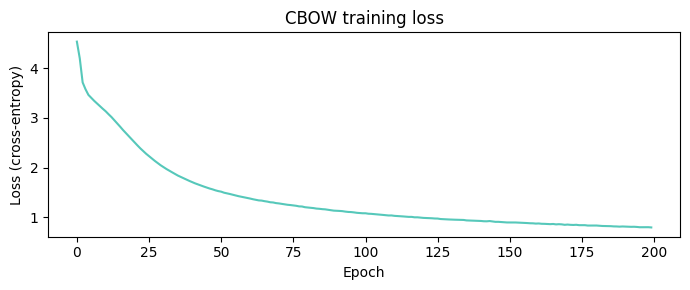

Final loss: 0.7953


In [31]:
history = model.fit(
    X_cbow, y_cbow,
    epochs=EPOCHS,
    batch_size=64,
    verbose=0,      # silent — too many epochs to print each one
)

# Plot training loss
plt.figure(figsize=(7, 3))
plt.plot(history.history['loss'], color='#56c8ba', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Loss (cross-entropy)')
plt.title('CBOW training loss')
plt.tight_layout()
plt.show()
print(f'Final loss: {history.history["loss"][-1]:.4f}')


### 7.6 — Extract embeddings and visualise with t-SNE


In [32]:
def extract_embeddings(
    model: tf.keras.Model,
    word2idx: dict,
    method: str = 'W1',
) -> dict:
    """
    Extract word embedding vectors from a trained CBOW model.

    Parameters
    ----------
    model : tf.keras.Model
        Trained CBOW model (output of build_cbow_model).
    word2idx : dict
        Word to index mapping.
    method : {'W1', 'W2', 'avg'}, optional
        Which weights to use as embeddings, by default 'W1'.
        'W1'  : rows of the first Dense layer weight matrix.
        'W2'  : columns of the second Dense layer weight matrix.
        'avg' : element-wise average of W1 rows and W2 columns.

    Returns
    -------
    dict
        Mapping from word (str) to embedding vector (np.ndarray).
    """
    W1 = model.layers[0].get_weights()[0]   # (vocab_size, embedding_dim)
    W2 = model.layers[1].get_weights()[0]   # (embedding_dim, vocab_size)

    if method == "W1":
        matrix = W1
    elif method == "W2":
        matrix = W2.T
    elif method == "avg":
        matrix = (W1 + W2.T) / 2.0
    else:
        raise ValueError(f"Unknown method: {method}")

    return {word: matrix[idx] for word, idx in word2idx.items()}


cbow_embeddings = extract_embeddings(model, word2idx, method='avg')
print(f'Extracted embeddings for {len(cbow_embeddings)} words')
print(f'Embedding dim: {next(iter(cbow_embeddings.values())).shape}')
print(f'Embedding for "king": {cbow_embeddings["king"].round(3)}')


Extracted embeddings for 101 words
Embedding dim: (10,)
Embedding for "king": [-2.004  2.057  0.995  0.041 -0.537  1.855 -0.581 -0.569  1.867 -1.045]


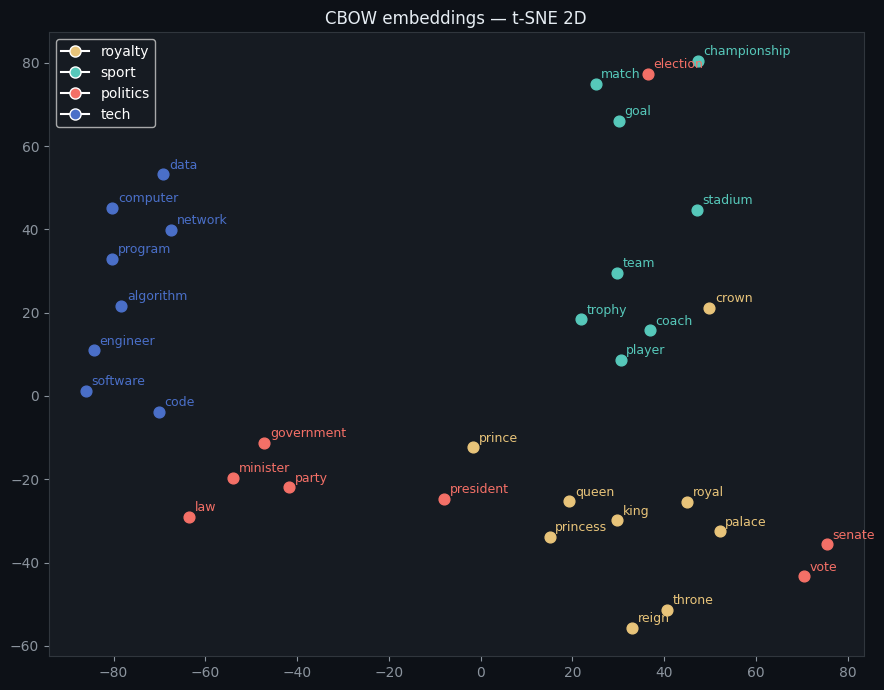

In [33]:
from sklearn.manifold import TSNE

# Words to visualise — the 4 domain clusters
DOMAIN_WORDS = {
    'royalty':  ['king', 'queen', 'prince', 'princess', 'throne', 'crown', 'palace', 'royal', 'reign'],
    'sport':    ['player', 'goal', 'match', 'team', 'coach', 'stadium', 'trophy', 'championship'],
    'politics': ['president', 'government', 'minister', 'election', 'vote', 'party', 'senate', 'law'],
    'tech':     ['algorithm', 'software', 'computer', 'network', 'data', 'code', 'program', 'engineer'],
}
DOMAIN_COLOURS = {
    'royalty':  '#e8c47a',  # gold
    'sport':    '#56c8ba',  # mint
    'politics': '#f47067',  # red
    'tech':     '#4a6fc8',  # navy
}

# Filter to words present in our trained vocabulary
plot_words   = []
plot_colours = []
plot_labels  = []
for domain, words in DOMAIN_WORDS.items():
    for w in words:
        if w in cbow_embeddings:
            plot_words.append(w)
            plot_colours.append(DOMAIN_COLOURS[domain])
            plot_labels.append(domain)

matrix = np.vstack([cbow_embeddings[w] for w in plot_words])

# t-SNE projection
# perplexity must be < n_samples; with ~32 words use 5
tsne   = TSNE(n_components=2, random_state=RANDOM_STATE,
              perplexity=5, init='pca', learning_rate='auto')
coords = tsne.fit_transform(matrix)

fig, ax = plt.subplots(figsize=(9, 7))
ax.set_facecolor('#161b22')
fig.patch.set_facecolor('#0d1117')

for i, word in enumerate(plot_words):
    ax.scatter(coords[i, 0], coords[i, 1],
               color=plot_colours[i], s=60, zorder=3)
    ax.annotate(word, (coords[i, 0], coords[i, 1]),
                fontsize=9, xytext=(4, 4),
                textcoords='offset points',
                color=plot_colours[i])

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=c, markersize=8, label=d)
    for d, c in DOMAIN_COLOURS.items()
]
ax.legend(handles=legend_elements, facecolor='#161b22',
          labelcolor='white', framealpha=0.8)
ax.set_title('CBOW embeddings — t-SNE 2D', color='#e6edf3')
ax.tick_params(colors='#8b949e')
ax.spines[:].set_color('#30363d')
plt.tight_layout()
plt.show()


**📝 Your analysis — Part 7**

1. The four domains form four visible clusters in the t-SNE plot. Royalty, sport, politics and tech each occupy a distinct region. The CBOW objective grouped words that share contexts.

2. A few function words like `the` or `of` sit between clusters since they appear in every domain. Words shared across topics such as `new` or `won` also drift toward the centre.

3. GloVe was trained on billions of tokens and reflects broad world knowledge. Our CBOW was trained on 100 sentences and only encodes the structure of this toy corpus. PCA on GloVe shows fine semantic axes like gender. t-SNE on our CBOW shows coarse domain blocks because the corpus has no within-domain variation.

4. With `EMBEDDING_DIM=2` and a direct scatter, the four clusters still appear but are tighter and less separable. Two dimensions are enough for four topics in a vocabulary of 100 words, though margins shrink.


---
## Summary

Run the cell below to print your final comparison table.

In [34]:
print(f"Dataset : {DATASET_NAME}")
print(f"GloVe   : glove-wiki-gigaword-{GLOVE_DIM}  ({GLOVE_DIM}d)")
print()
display(comparison)
print()
print("What's next:")
print("  TP 05 — LSTM sequence classifier.")
print("  Word order finally enters the picture.")

Dataset : fancyzhx/ag_news
GloVe   : glove-wiki-gigaword-50  (50d)



,Session,Model,Val Macro F1,Test Macro F1
0,S01,Majority,0.250000,0.250000
1,S03,Naive Bayes,NaN,NaN
2,S03,LR + TF-IDF,NaN,NaN
3,S04 (this),LR + GloVe mean pool,0.893928,0.873943



What's next:
  TP 05 — LSTM sequence classifier.
  Word order finally enters the picture.
